# Woche 7: Data Cleaning - Übung am eigenen Projekt

**Ziel dieser Übung:** Nachdem Sie die wichtigsten Aspekte des Data Cleanings am Airbnb-Beispiel kennengelernt haben, wenden Sie dieses Wissen Schritt für Schritt auf Ihren eigenen Datensatz an.

**Arbeitsweise:**
- Arbeiten Sie die Aufgaben nacheinander durch
- Nutzen Sie die Code-Zellen für Ihre Implementierung
- Orientieren Sie sich an den Beispielen aus dem Airbnb-Notebook
- Das bereinigte Dataset speichern Sie am Ende ab

---
## 1. Daten einlesen und Bibliotheken importieren

**Aufgabe:** Importieren Sie die notwendigen Bibliotheken und laden Sie Ihren Datensatz.

**Hinweise:**
- Importieren Sie: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`
- Setzen Sie einen Zufallsseed für Reproduzierbarkeit
- Laden Sie Ihren CSV-Datensatz mit `pd.read_csv()`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



np.random.seed(101) #Seed setzen

data = pd.read_csv('diabetesdata.csv') #CSV-Datei lesen

data_clean = data.copy() #Copy erstellen



---
## 2. Ersten Überblick verschaffen

**Aufgabe:** Verschaffen Sie sich einen ersten Überblick über Ihren Datensatz.

**Was Sie prüfen sollten:**
- Wie viele Zeilen und Spalten hat der Datensatz?
- Welche Spalten gibt es und welche Datentypen haben sie?
- Wie sehen die ersten Zeilen aus?

In [2]:
print(f"Der Datensatz enthält: {data_clean.shape[0]} Zeilen und {data_clean.shape[1]} Spalten") #Datensatzdimension anzeigen

display(data.head()) #Übersicht erste Zeilen anzeigen

display(data_clean.iloc[0]) # Erste Zeilen anzeigen

display(data_clean.dtypes)  # Informationen zu Spalten und Datentypen

Der Datensatz enthält: 768 Zeilen und 9 Spalten


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                       0.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

---
## 3. Fehlende Werte identifizieren

**Aufgabe:** Untersuchen Sie Ihren Datensatz auf fehlende Werte.

**Was Sie tun sollten:**
- Zählen Sie fehlende Werte pro Spalte
- Berechnen Sie den Prozentsatz fehlender Werte
- Visualisieren Sie fehlende Werte (optional: Heatmap)

,Spalte,Fehlend,Prozent
1,Glucose,5,0.651042
2,BloodPressure,35,4.557292
3,SkinThickness,227,29.557292
4,Insulin,374,48.697917
5,BMI,11,1.432292


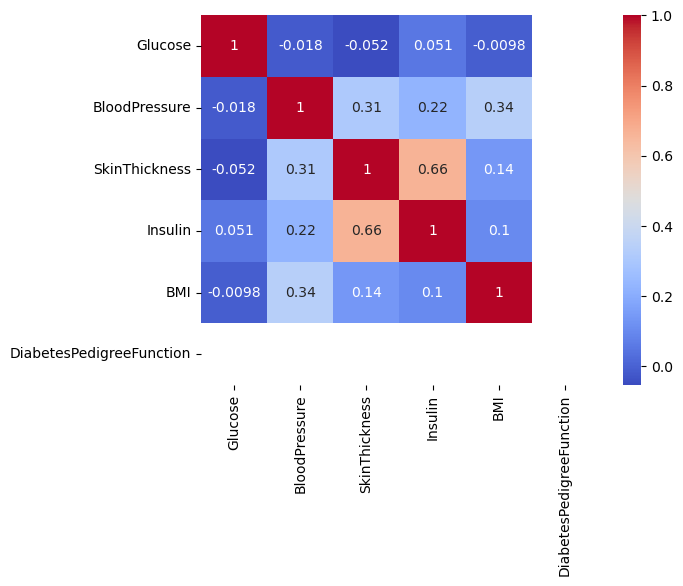

In [3]:

data_missing_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']  # Spalten mit Null-Werten definieren (außer Pregnancies/Outcome)

data_clean[data_missing_columns] = data_clean[data_missing_columns].replace(0, np.nan) # Null-Werte durch NaN ersetzen

# Fehlende Werte visualisieren

def missing_data_display(df):
    # Fehlende Werte zählen
    data_missing = df.isnull().sum()
    
    # Prozent berechnen
    data_missing_percent = (data_missing / len(df)) * 100
    
    # Tabelle erstellen
    missing_table = pd.DataFrame({
        "Spalte": data_missing.index,
        "Fehlend": data_missing.values,
        "Prozent": data_missing_percent.values
    })
    
    # Nur Spalten mit Missing Values
    missing_table = missing_table[missing_table["Fehlend"] > 0]
    
    return missing_table

display(missing_data_display(data_clean))

# Heatmap der Korrelation der fehlenden Werte erstellen

sns.heatmap(
    data_clean[data_missing_columns].isnull().corr(),
    annot=True,
    cmap="coolwarm"
) #HeatMap generieren

plt.show()

---
## 4. Fehlende Werte behandeln

**Aufgabe:** Entscheiden Sie für jede Spalte mit fehlenden Werten, wie Sie damit umgehen.

**Mögliche Strategien:**
- Zeilen löschen (bei wenigen fehlenden Werten)
- Spalten löschen (bei sehr vielen fehlenden Werten)
- Fehlende Werte imputieren:
  - Numerische Spalten: Median oder Mittelwert
  - Kategoriale Spalten: Modus oder neue Kategorie

**Dokumentieren Sie Ihre Entscheidungen!**

 Bei SkinThickness (~30 %) und Insulin (~49 %) fehlen sehr viele Werte. Ein Löschen der Zeilen würde den Datensatz stark verkleinern, ein Löschen der Spalten wichtige Merkmale entfernen, sodass beide Optionen nicht in Frage kommen.

Stattdessen erfolgt eine Median-Imputation. Der Median ist robust gegenüber Ausreißern. Eine positionsbasierte Interpolation wurde nach Korrektur nicht mehr verwendet, da die Zeilen keine sinnvolle Reihenfolge besitzen (Querschnittsdaten) und eine lineare Interpolation über den Index inhaltlich nicht begründbar wäre.

In [4]:

data_clean[data_missing_columns] = data_clean[data_missing_columns].fillna(data_clean[data_missing_columns].median()) # Fehlende Werte mit Median ersetzen


display(missing_data_display(data_clean))




,Spalte,Fehlend,Prozent


---
## 5. Duplikate identifizieren und entfernen

**Aufgabe:** Prüfen Sie, ob Ihr Datensatz doppelte Zeilen enthält.

**Was Sie tun sollten:**
- Zählen Sie die Anzahl doppelter Zeilen
- Entfernen Sie Duplikate (falls vorhanden)
- Überprüfen Sie die neue Anzahl der Zeilen

In [5]:
dups = data_clean.duplicated().sum() # Summierung möglicher Duplikate (gesamte Zeile, da keine ID vorhanden)

print("Duplikate:", dups)

data_clean = data_clean.drop_duplicates() # Löschung von Duplikaten

print(f"Nach Entfernung: {data_clean.shape[0]} Zeilen") # Vergleich mit vorherigem Datensatz

Duplikate: 0
Nach Entfernung: 768 Zeilen


---
## 6. Datentypen überprüfen und anpassen

**Aufgabe:** Stellen Sie sicher, dass alle Spalten die richtigen Datentypen haben.

**Was Sie prüfen sollten:**
- Sind numerische Spalten als `int` oder `float` kodiert?
- Sind kategoriale Spalten als `object` oder `category` kodiert?
- Müssen Datentypen konvertiert werden?

In [6]:

display(data_clean.dtypes) # Datentypen anzeigen

int_data = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin'] # Spalten für Int-Werte festlegen, da numerische Werte

data_clean[int_data] = data_clean[int_data].astype('int') # Datentyp anpassen

display(data_clean.dtypes) # Datentypen anzeigen zur Kontrolle


Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

---
## 7. Ausreißer identifizieren

**Aufgabe:** Identifizieren Sie Ausreißer in numerischen Spalten.

**Methoden:**
- Visualisierung mit Boxplots
- IQR-Methode (Interquartile Range)
- Statistische Analyse (describe)

**Wichtig:** Entscheiden Sie für jeden Ausreißer, ob er:
- Ein Fehler ist (→ entfernen oder korrigieren)
- Ein echter extremer Wert ist (→ behalten)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


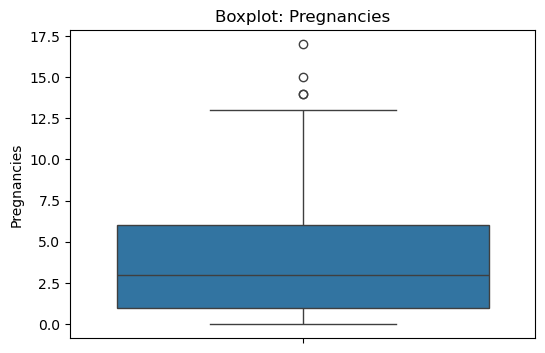

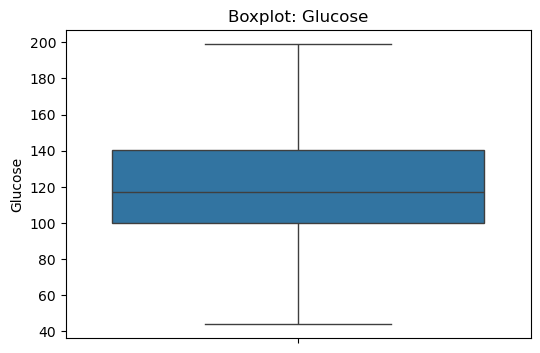

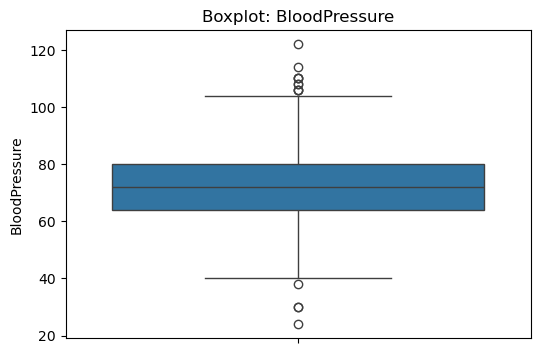

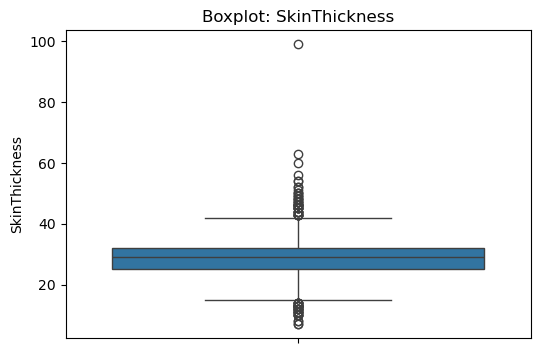

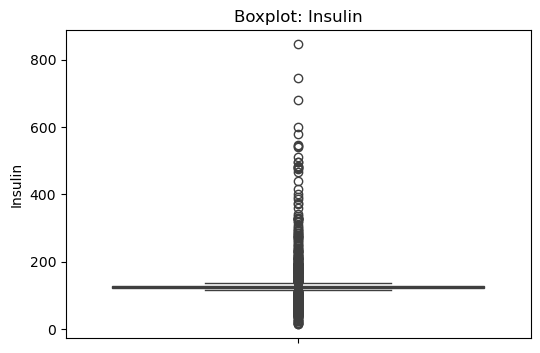

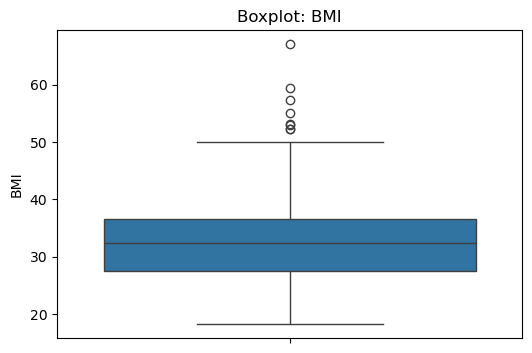

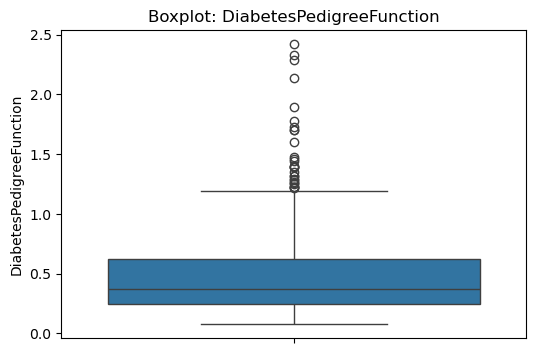

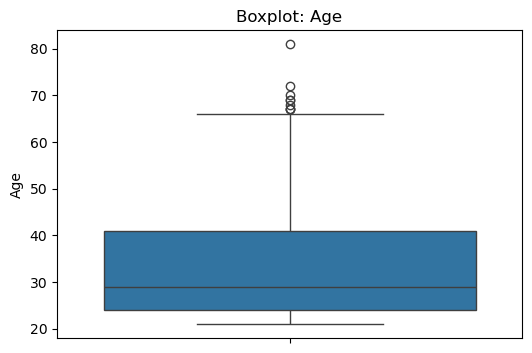

In [7]:

numeric_cols = data_clean.select_dtypes(include=['int64', 'float64']).columns #Numerische Spalten filtern

numeric_cols = numeric_cols[:-1] # Outcome entfernen

display(data_clean[numeric_cols].describe())  # Statistische Übersicht

for column in numeric_cols: # Einzelne BoxPlots generieren
    plt.figure(figsize=(6,4))
    sns.boxplot(y=data_clean[column])
    plt.title(f"Boxplot: {column}")
    plt.show()


In [8]:
#Ausgabe der Außreißer für jede Spalte


for colum in numeric_cols:
    Q1 = data_clean[colum].quantile(0.25)
    Q3 = data_clean[colum].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_clean[(data_clean[colum] < lower_bound) | (data_clean[colum] > upper_bound)]
    
    print(f"Ausreißer bei {colum}:\n{outliers[colum]}")


Ausreißer bei Pregnancies:
88     15
159    17
298    14
455    14
Name: Pregnancies, dtype: int64
Ausreißer bei Glucose:
Series([], Name: Glucose, dtype: int64)
Ausreißer bei BloodPressure:
18      30
43     110
84     108
106    122
125     30
177    110
362    108
549    110
597     24
599     38
658    106
662    106
672    106
691    114
Name: BloodPressure, dtype: int64
Ausreißer bei SkinThickness:
8      45
16     47
32     11
39     47
50     11
       ..
698    11
710    13
718    46
753    44
763    48
Name: SkinThickness, Length: 87, dtype: int64
Ausreißer bei Insulin:
3       94
4      168
6       88
8      543
13     846
      ... 
753    510
755    110
760     16
763    180
765    112
Name: Insulin, Length: 346, dtype: int64
Ausreißer bei BMI:
120    53.2
125    55.0
177    67.1
193    52.3
247    52.3
303    52.9
445    59.4
673    57.3
Name: BMI, dtype: float64
Ausreißer bei DiabetesPedigreeFunction:
4      2.288
12     1.441
39     1.390
45     1.893
58     1.781
100  

---
## 8. Ausreißer behandeln

**Aufgabe:** Behandeln Sie die identifizierten Ausreißer entsprechend Ihrer Analyse.

**Mögliche Strategien:**
- Ausreißer entfernen (wenn sie Fehler sind)
- Ausreißer behalten (wenn sie valide sind)
- Ausreißer begrenzen (Capping/Flooring)

**Dokumentieren Sie Ihre Entscheidungen!**

Außreißer:

Bloodpressure (Werte unterhalb und oberhalb der IQR-Grenze) --> Entfernen, da ein Blutdruck unterhalb von 40 mmHg oder oberhalb von 110 mmHg einem medizinschem Notfall entspricht und im Rahmen einer Routineerhebung als Messfehler gesehen werden sollte  

SkinThickness (Werte über 80 mm) --> Entfernen, da Werte über 80 mm physiologisch bzw. anatomisch unrealistisch erscheinen. Ausreißer unterhalb dieses gesetzten Cut-Off-Wertes sind bei schwerer Adipositas durchaus erwartbar  

Pregnancies (hohe Werte) --> Behalten, Ausreßer bei mehrfachen Zwillings- oder Mehrlingsgeburten selten aber denkbar  

Insulin (hohe Werte) --> Behalten, insgesamt deutliche Verschiebung nach rechts, hohe Werte sind im Rahmen einer Insulinresistenz realistisch  

DiabetesPedigreeFunction (hohe Werte) --> Behalten, alle Werte liegen in der maximalen Range von 0.078 - 2.42  

Age (hohe Werte) --> Behalten, alle Werte liegen im plausiblen Bereich (21- 81 Jahre)


In [9]:
# Außreißer für niedrigen und hohen Blutdruck entfernen (am ehesten fehlerhafte Werte)

Q1 = data_clean['BloodPressure'].quantile(0.25)
Q3 = data_clean['BloodPressure'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = 40
upper_bound = 110

data_clean = data_clean[(data_clean['BloodPressure'] >= lower_bound) & (data_clean['BloodPressure'] <= upper_bound)]


print(f"Nach Entfernung: {data_clean.shape[0]} Zeilen") 

# Manuelle Entfernung eines Ausreißers bei der SkinThickness

data_clean = data_clean[(data_clean['SkinThickness'] <= 80)]

print(f"Nach Entfernung: {data_clean.shape[0]} Zeilen") 




Nach Entfernung: 762 Zeilen
Nach Entfernung: 761 Zeilen


---
## 9. Inkonsistenzen beheben

**Aufgabe:** Suchen Sie nach Inkonsistenzen in kategorialen Spalten.

**Was Sie prüfen sollten:**
- Unterschiedliche Schreibweisen (z.B. "ja", "Ja", "JA")
- Leerzeichen am Anfang oder Ende
- Tippfehler
- Unerwartete Kategorien

In [10]:
# Keine kategorialen Spalten

In [11]:
#Feature Engineering von Adipositas bzw. Gewichteinteilung

data_clean['Adipositas'] = pd.cut(data_clean['BMI'],
                                bins=[0, 18.5, 25, 30, 35, 40, 100],
                                labels=['untergewichtig', 'normalgewichtig', 'praeadipositas', 'adipositas_grade_I', 'adipositas_grade_II', 'adipositas_grade_III'])

data_clean = data_clean[['Pregnancies',
         'Glucose',
         'BloodPressure',
         'SkinThickness',
         'Insulin',
         'BMI',
         'Adipositas',
         'DiabetesPedigreeFunction',
         'Age',
         'Outcome']]


display(data_clean.head())


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Adipositas,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,adipositas_grade_I,0.627,50,1
1,1,85,66,29,125,26.6,praeadipositas,0.351,31,0
2,8,183,64,29,125,23.3,normalgewichtig,0.672,32,1
3,1,89,66,23,94,28.1,praeadipositas,0.167,21,0
4,0,137,40,35,168,43.1,adipositas_grade_III,2.288,33,1


---
## 10. Finale Überprüfung

**Aufgabe:** Führen Sie eine finale Qualitätskontrolle durch.

**Checkliste:**
- ✓ Keine fehlenden Werte (oder bewusst belassen)
- ✓ Keine Duplikate
- ✓ Korrekte Datentypen
- ✓ Ausreißer behandelt
- ✓ Inkonsistenzen behoben
- ✓ Datensatz ist bereit für die Analyse

In [12]:
# Finale Übersicht
print("Finale Dimensionen:")
print(data_clean.shape)

print("\nFehlende Werte:")
print(data_clean.isnull().sum())

print("\nDatentypen:")
print(data_clean.dtypes)

print("\nErste Zeilen des bereinigten Datensatzes:")
display(data_clean.head())


Finale Dimensionen:
(761, 10)

Fehlende Werte:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
Adipositas                  0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Datentypen:
Pregnancies                    int64
Glucose                        int64
BloodPressure                  int64
SkinThickness                  int64
Insulin                        int64
BMI                          float64
Adipositas                  category
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                        int64
dtype: object

Erste Zeilen des bereinigten Datensatzes:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Adipositas,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,adipositas_grade_I,0.627,50,1
1,1,85,66,29,125,26.6,praeadipositas,0.351,31,0
2,8,183,64,29,125,23.3,normalgewichtig,0.672,32,1
3,1,89,66,23,94,28.1,praeadipositas,0.167,21,0
4,0,137,40,35,168,43.1,adipositas_grade_III,2.288,33,1


---
## 11. Bereinigten Datensatz speichern

**Aufgabe:** Speichern Sie Ihren bereinigten Datensatz als CSV-Datei.

**Wichtig:** Dieser bereinigte Datensatz wird in den kommenden Wochen für Visualisierung und Machine Learning verwendet!

In [13]:
# Bereinigten Datensatz speichern
data_clean.to_csv('diabetesdata_cleaned.csv', index=False)

print("Bereinigter Datensatz wurde gespeichert!")

Bereinigter Datensatz wurde gespeichert!


---
## Reflexion

**Dokumentieren Sie Ihre Arbeit:**

Beantworten Sie folgende Fragen in einer Markdown-Zelle:

1. Welche Hauptprobleme hatte Ihr ursprünglicher Datensatz?
2. Welche Bereinigungsschritte waren am wichtigsten?
3. Wie viele Zeilen/Spalten haben Sie entfernt und warum?
4. Welche Herausforderungen gab es und wie haben Sie diese gelöst?
5. Ist Ihr Datensatz jetzt bereit für die Analyse?

### Ihre Reflexion:


**1. Hauptprobleme des ursprünglichen Datensatzes**
- Fehlende Messwerte waren als "0" kodiert und mussten zunächst als solche erkannt werden. Betroffen waren fünf Spalten mit physiologisch unmöglichen Nullwerten: Insulin (374 / ~48,7 %), SkinThickness (227 / ~29,6 %), BloodPressure (35), BMI (11) und Glucose (5). Dabei war zu berücksichtigen, dass eine 0 bei Pregnancies ein gültiger natürlicher Wert ist und nicht umkodiert werden darf.
- Zusätzlich enthielten einzelne Spalten physiologisch unmögliche Extremwerte (sehr niedriger oder hoher Blutdruck, Hautfaltendicke von 99 mm).

**2. Wichtigste Bereinigungsschritte**
- Umkodierung der 0-Werte in NaN  bei den inhaltlich passenden Spalten
- Auffüllen der fehlenden Werte per Median-Imputation, um den Stichprobenumfang zu erhalten, statt Zeilen oder wichtige Spalten zu löschen.
- Ausreißerbehandlung und Feature Engineering der BMI-Kategorien

**3. Entfernte Zeilen/Spalten und Begründung**
- Duplikate: 0 (keine vollständigen Zeilenduplikate vorhanden).
- Ausreißer: 6 Zeilen bei BloodPressure (Wert < 40 mmHg bzw. > 110 mmHg, medizinischer Notfall, am ehesten Messfehler) und 1 Zeile bei SkinThickness (99 mm, anatomisch unmöglich) → insgesamt 7 entfernte Zeilen.
- Ergebnis: 768 → 761 Zeilen, entspricht einer Retention-Rate von 99,09 %. Es wurde keine Spalte entfernt; durch das Feature Engineering wurde die Spalte "Adipositas " hinzugefügt.
- Ausreißer bei Pregnancies, Insulin, DiabetesPedigreeFunction und Age wurden bewusst behalten, da es sich um valide, wenn auch seltene Werte handelt (siehe Abschnitt 8).

**4. Herausforderungen und Lösungen**
- Die größte Herausforderung war die als "0" maskierte Fehlwert-Kodierung, die eine fachliche Unterscheidung zwischen echten und unmöglichen Nullwerten erforderte.
- Die hohe Fehlwertquote bei Insulin und SkinThickness sprach gegen ein Löschen; die Median-Imputation stellte einen Kompromiss zwischen Datenerhalt und Verzerrung dar.

**5. Bereitschaft für die Analyse**
- Ja. Der Datensatz enthält keine fehlenden Werte oder Duplikate mehr, hat konsistente Datentypen und behandelte Ausreißer. Einschränkend ist zu beachten, dass ein großer Anteil imputierter Werte (insbesondere bei Insulin) die Verteilung dieser Merkmale glättet, was für die folgende Analyse von Relevanz sein kann.